In [1]:
#calcZ.ipynb
from numpy import *
import numpy as np


dbinsM=(0.025+arange(300)*0.05)
massW=(0.1*dbinsM)**3/6.*pi
dMax=10.*(massW/0.0061)**(1/2.05)



In [4]:

freqs=['13.8','35.00','94.00','183.31', '325.15','660.00','684.00']
wlL=[]
for f in freqs:
    ff=float(f)
    wlf=300./ff
    #print(wlf)
    wlL.append(wlf)


In [7]:
import matplotlib.pyplot as plt
import netCDF4 as nc
freqs=['13.8','35.00','94.00','183.31','325.15','660.00','684.00']
kextL=[]
bscatL=[]
kscaL=[]
gL=[]
dmL=[]
for f in freqs[:]:
    fh=nc.Dataset('/Users/mgrecu/Tables/SSP/ice-self-similar-aggregates_%s-GHz_scat.nc'%f)
    mass= fh['mass'][:]
    dm= fh['mean_dimension'][:]
    ext= fh['ext'][:]
    scat= fh['scat'][:]
    g= fh['g'][:]
    bscat= fh['bscat'][:]

    wavelength= fh['wavelength'][:]
    wl_srg=wavelength*1e3
    # get the diamter from the mass assuming a density of 1000 kg/m^3
    rhow=1000.
    d=(6*mass/pi/rhow)**(1/3.)*1e3 # mm
    bscat=bscat*4*pi*wl_srg**4/pi**5*1e6    # mm^6
    kext=ext*1e6
    ksca=scat*1e6    
    #print(fh['bscat'])
    #print(fh)
    print(wavelength,f,wl_srg)
    kextL.append(kext[3,:])
    bscatL.append(bscat[3,:])
    kscaL.append(ksca[3,:])
    gL.append(g[3,:])
    dmL.append(d[:])
    #break



0.02174 13.8 21.740000694990158
0.00857 35.00 8.569999597966671
0.00319 94.00 3.1900000758469105
0.00164 183.31 1.6400000313296914
0.00092 325.15 0.9200000204145908
0.00045 660.00 0.44999999227002263
0.00044 684.00 0.4400000034365803


In [11]:
dmL=array(dmL)
kextL=array(kextL)
bscatL=array(bscatL)
kscaL=array(kscaL)
gL=array(gL)
print(dmL.shape)

(7, 25, 200)


In [5]:
dmL=array(dmL)
kextL=array(kextL)
bscatL=array(bscatL)
kscaL=array(kscaL)
gL=array(gL)
print(dmL.shape)
print(kextL.shape)
print(bscatL.shape)
print(kscaL.shape)
print(gL.shape)

(7, 25, 200)
(7, 25, 200)
(7, 25, 200)
(7, 25, 200)
(7, 25, 200)


In [6]:

import xarray as xr
dmX=xr.DataArray(dmL,dims=['freq','fract','size'])
kextX=xr.DataArray(kextL,dims=['freq','fract','size'])
bscatX=xr.DataArray(bscatL,dims=['freq','fract','size'])
kscaX=xr.DataArray(kscaL,dims=['freq','fract','size'])
gX=xr.DataArray(gL,dims=['freq','fract','size'])
freqX=xr.DataArray([float(freq) for freq in freqs],dims=['freq'])
dmX.attrs['units']='mm'
kextX.attrs['units']='mm^2'
bscatX.attrs['units']='mm^6'
kscaX.attrs['units']='mm^2'
gX.attrs['units']=''
ds=xr.Dataset({'dm':dmX,'kext':kextX,'bscat':bscatX,'ksca':kscaX,'g':gX,'freq':freqX})


ds.to_netcdf('ice_SSRG_SSP.nc')

In [15]:
rhow=1 #gcm-3
dD=0.05
from scipy.special import gamma as gam
mu=2.0
Dint=np.arange(260)*dD+dD/2.0
Deq=dm
rwc=(np.logspace(-4,1.25,300))
Nw=0.08e8
Dm=(4**4*rwc/(np.pi*1e6*Nw))**0.25*1e3 # in mm
f_mu=6/4**4*(4+mu)**(mu+4)/gam(mu+4)
lambd=(4+mu)/Dm
zAllL=[]
kextAllL=[]
kscaAllL=[]
gAllL=[]
ifract=4
K2=0.93
for bsca1,ext1,scat1,g1 in zip(bscatL,kextL,kscaL,gL):
    Deq=dmL[0][ifract]
    bscatInt=np.exp(np.interp(Dint,Deq,np.log(bsca1[ifract])))  #mm^6
    extInt=np.exp(np.interp(Dint,Deq,np.log(ext1[ifract])))     #mm^2
    scatInt=np.exp(np.interp(Dint,Deq,np.log(scat1[ifract])))   #mm^2
    gInt=np.interp(Dint,Deq,(g1[ifract]))  #dimensionless
    massW=np.pi/6*(Dint*0.1)**3*rhow
    mL=[]
    zTrueL=[]
    kextfL=[]
    kscatfL=[]
    gfL=[]
    for lambd1,dm1 in zip(lambd,Dm):
        Nd=f_mu*np.exp(-lambd1*Dint)*(Dint/dm1)**mu*dD #(mm)
        M=sum(Nd*massW*Nw*1e-3)
        zTrue=log10(sum(Nw*1e-3*Nd*bscatInt/K2)+1e-9)*10.
        kext=sum(Nd*Nw*1e-3*extInt)*1e-3
        kscat=sum(Nd*Nw*1e-3*scatInt)*1e-3
        g1=sum(Nd*Nw*1e-3*scatInt*gInt)*1e-3/kscat
        mL.append(M)
        zTrueL.append(zTrue)
        kextfL.append(kext)
        kscatfL.append(kscat)
        gfL.append(g1)
    zAllL.append(zTrueL)
    kextAllL.append(kextfL)
    kscaAllL.append(kscatfL)
    gAllL.append(gfL)
    #break


(25, 200)
(7, 25, 200)
['Dataset', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__spec__', 'getBBProp', 'getGraupProp', 'getRainProp', 'getSnowProp', 'scattTables']


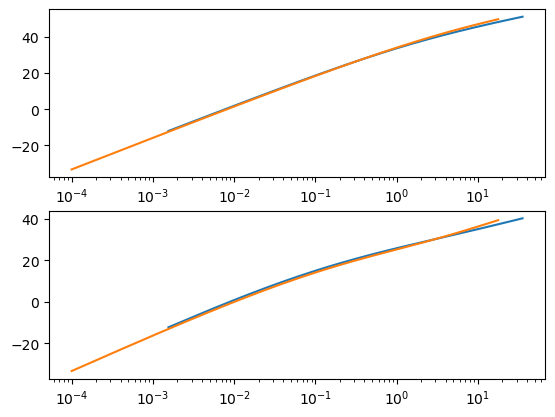

In [16]:
print(bsca1.shape)
print(dmL.shape)
#plt.subplot(111)
zAllL=array(zAllL)
#plt.semilogx(mL,zAllL[0])
import lkTables as lkt
print(dir(lkt))
lkTables=lkt.scattTables()
#plt.semilogx(lkTables.rwc,lkTables.zKuR)
plt.figure()
plt.subplot(211)
plt.semilogx(lkTables.swc,lkTables.zKuS)
plt.semilogx(mL,zAllL[0])
plt.subplot(212)
plt.semilogx(lkTables.swc,lkTables.zKaS)
plt.semilogx(mL,zAllL[1])
#plt.semilogx(mL,np.array(kextfL)*4.343)
#plt.subplot(212)
#plt.plot(mL,gfL)

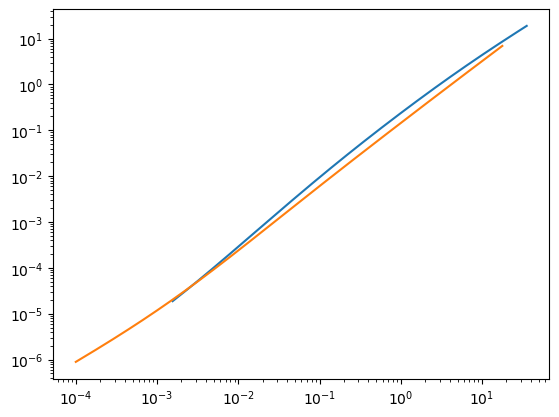

In [17]:
plt.loglog(lkTables.swc,lkTables.attKaS)

plt.loglog(mL,np.array(kextAllL)[1,:]*4.343)

In [19]:
import xarray as xr
zAllX=xr.DataArray(zAllL,dims=['freq','rwc'])
kextAllX=xr.DataArray(kextAllL,dims=['freq','rwc'])
kscaAllX=xr.DataArray(kscaAllL,dims=['freq','rwc'])
gAllX=xr.DataArray(gAllL,dims=['freq','rwc'])
rwcX=xr.DataArray(rwc,dims=['rwc'])
dmX=xr.DataArray(Dm,dims=['rwc'])
freqX=xr.DataArray([float(freq) for freq in freqs],dims=['freq'])
zAllX.attrs['units']='dBZ'
kextAllX.attrs['units']='1/km'
kscaAllX.attrs['units']='1/km'
gAllX.attrs['units']=''
rwcX.attrs['units']='g/m^3'
dmX.attrs['units']='mm'
ds=xr.Dataset({'dm':dmX,'kext':kextAllX,'bscat':kscaAllX,'ksca':kscaAllX,'g':gAllX,'rwc':rwcX,'freq':freqX})
ds.to_netcdf('ice_SSRG_integrated_prop.nc')